In [255]:
import csv
import matplotlib.pyplot as plt
import numpy as np

# Représentations graphiques

Exercice 1 :

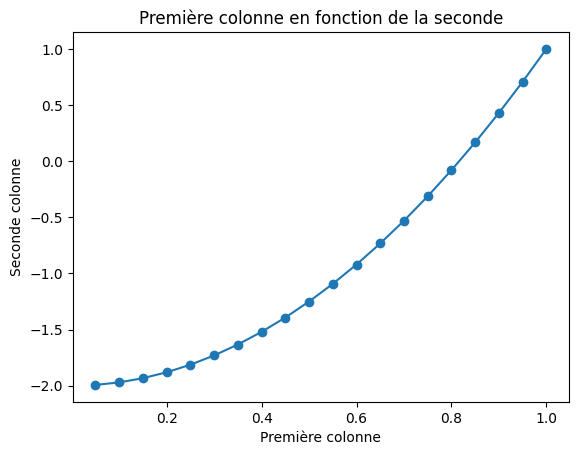

In [256]:
data = np.genfromtxt('donnees2.csv', delimiter=',', skip_header=1)

plt.plot(data[:, 0], data[:, 1], marker='o')
plt.xlabel('Première colonne')
plt.ylabel('Seconde colonne')
plt.title('Première colonne en fonction de la seconde')
plt.show()

Exercice 2

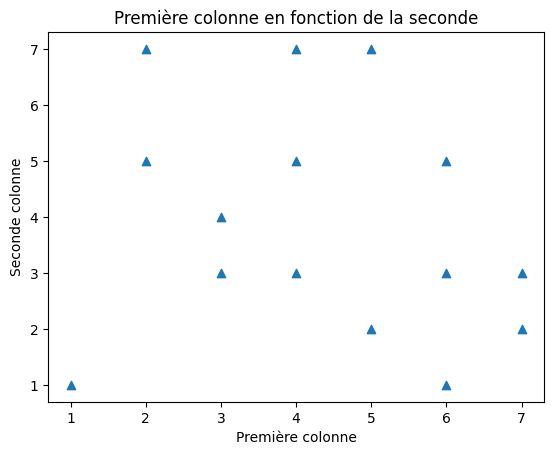

In [257]:
data3 = np.genfromtxt('donnees3.csv', delimiter=',', skip_header=1)

plt.scatter(data3[:, 0], data3[:, 1], marker='^')
plt.xlabel('Première colonne')
plt.ylabel('Seconde colonne')
plt.title('Première colonne en fonction de la seconde')
plt.show()

Exercice 3

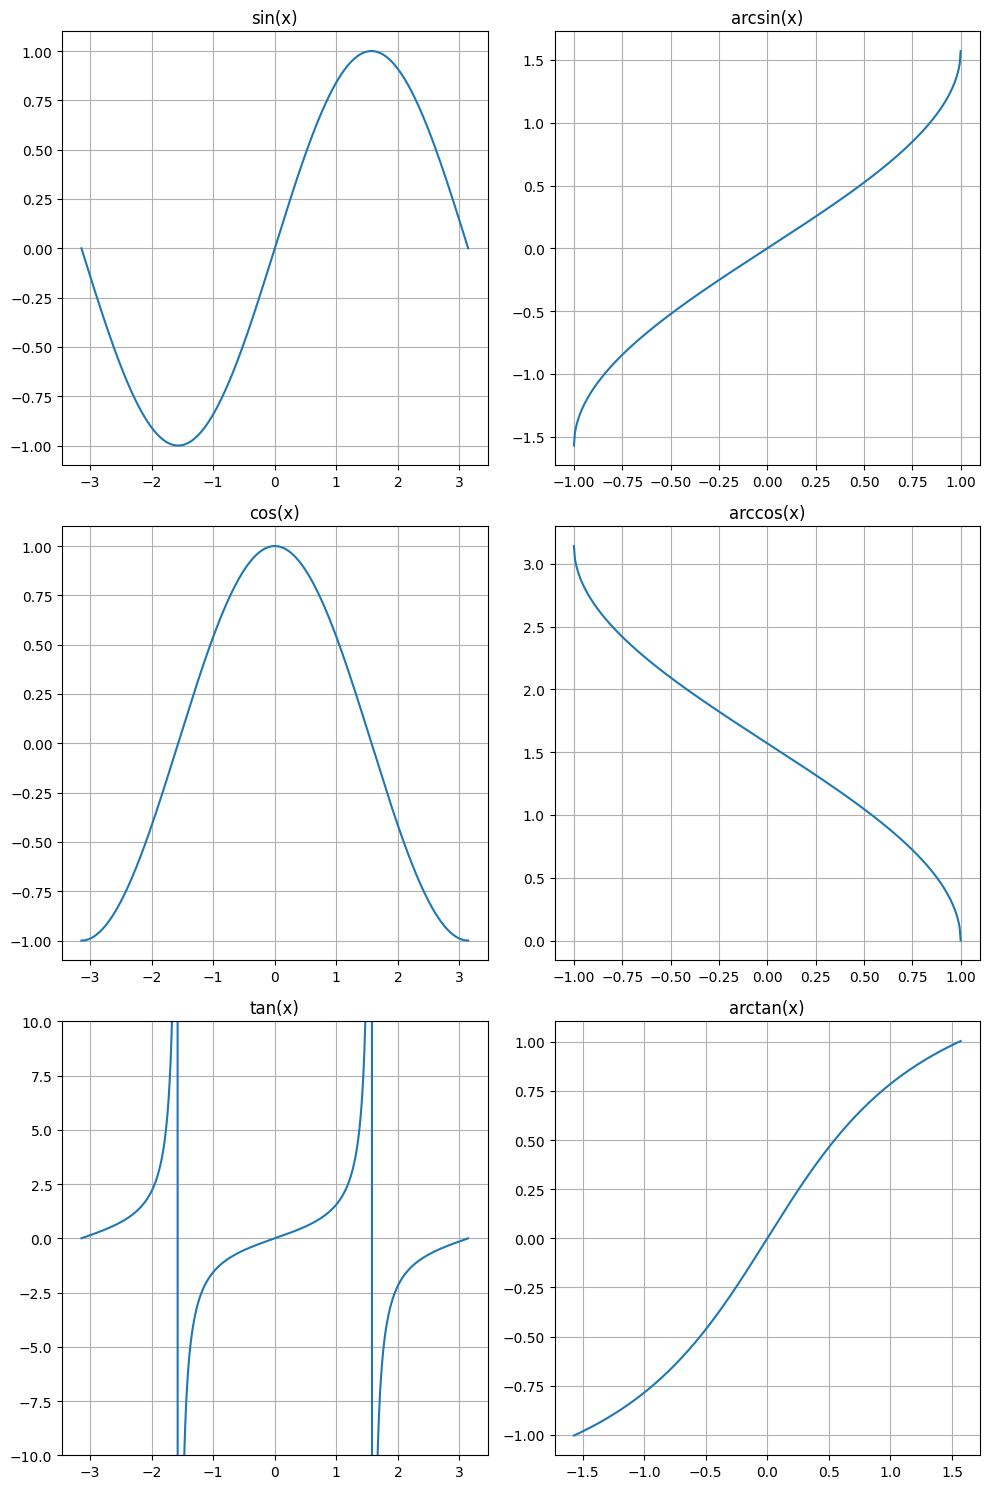

In [258]:
x = np.linspace(-np.pi, np.pi, 400)
y_sin = np.sin(x)
y_cos = np.cos(x)
y_tan = np.tan(x)

x_reciprocal = np.linspace(-1, 1, 400)
y_arcsin = np.arcsin(x_reciprocal)
y_arccos = np.arccos(x_reciprocal)

x_arctan = np.linspace(-np.pi/2, np.pi/2, 400)
y_arctan = np.arctan(x_arctan)

fig, axs = plt.subplots(3, 2, figsize=(10, 15))
# Add grid to all subplots
for ax in axs.flat:
    ax.grid(True)
    
# Plot sin and arcsin
axs[0, 0].plot(x, y_sin)
axs[0, 0].set_title('sin(x)')
axs[0, 1].plot(x_reciprocal, y_arcsin)
axs[0, 1].set_title('arcsin(x)')

# Plot cos and arccos
axs[1, 0].plot(x, y_cos)
axs[1, 0].set_title('cos(x)')
axs[1, 1].plot(x_reciprocal, y_arccos)
axs[1, 1].set_title('arccos(x)')

# Plot tan and arctan
axs[2, 0].plot(x, y_tan)
axs[2, 0].set_ylim(-10, 10)  # Limit y-axis for better visualization
axs[2, 0].set_title('tan(x)')
axs[2, 1].plot(x_arctan, y_arctan)
axs[2, 1].set_title('arctan(x)')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))

# Plot sin(x), cos(x), tan(x)
plt.plot(x, y_sin, label='sin(x)')
plt.plot(x, y_cos, label='cos(x)')
plt.plot(x, y_tan, label='tan(x)')

# Plot arcsin(x), arccos(x), arctan(x)
plt.plot(x_reciprocal, y_arcsin, label='arcsin(x)')
plt.plot(x_reciprocal, y_arccos, label='arccos(x)')
plt.plot(x_arctan, y_arctan, label='arctan(x)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Tracé de sin(x), cos(x), tan(x), arcsin(x), arccos(x) et arctan(x)')
plt.legend()
plt.grid(True)
plt.ylim(-10, 10)  # Limiter l'axe y pour une meilleure visualisation
plt.show()

Exercice 4

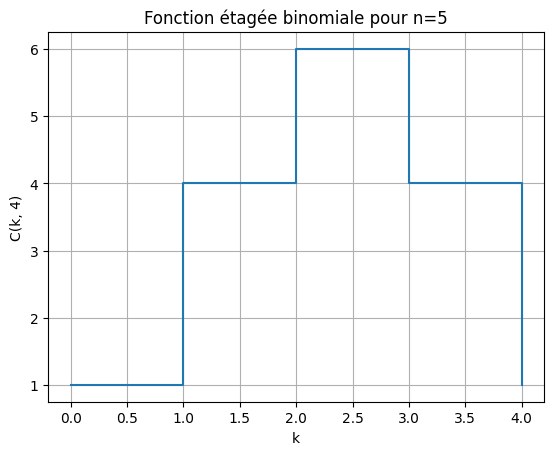

In [259]:
from scipy.special import comb

def plot_binomial_step_function(n):
    import matplotlib.pyplot as plt

    x = np.arange(0, n)
    y = [comb(n-1, k) for k in x]

    plt.step(x, y, where='post')
    plt.xlabel('k')
    plt.ylabel(f'C(k, {n-1})')
    plt.title(f'Fonction étagée binomiale pour n={n}')
    plt.grid(True)
    plt.show()

# Exemple d'utilisation
plot_binomial_step_function(5)

Exercice 5 :

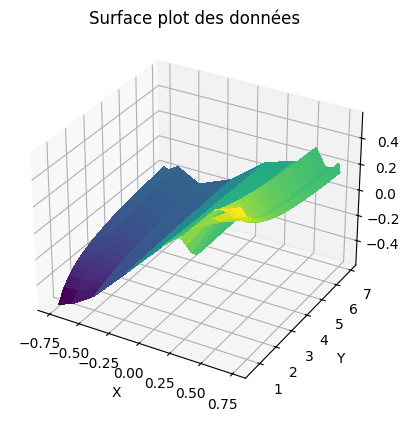

In [260]:
from mpl_toolkits.mplot3d import Axes3D

data4 = np.genfromtxt('donnees4.csv', delimiter=',', skip_header=1)

# Extraire les coordonnées X, Y et les valeurs Z
X, Y = np.meshgrid(data4[0, 1:], data4[1:, 0])
Z = data4[1:, 1:]

# Créer une figure 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# surface
ax.plot_surface(X, Y, Z, antialiased= False, cmap='viridis')

# Ajouter des étiquettes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Surface plot des données')

plt.show()

# Simulation de variables aléatoires

Exercice 6 : Simuler une matrice (Mi,j )i=1...100,j=1...200 contenant 100 échantillons de taille 200 de
variables aléatoires de loi exponentielle de paramètre 1. Pour illustrer le théorème central limite,
tracer l’histogramme associé et sur le même graphique la densité gaussienne correspondante.

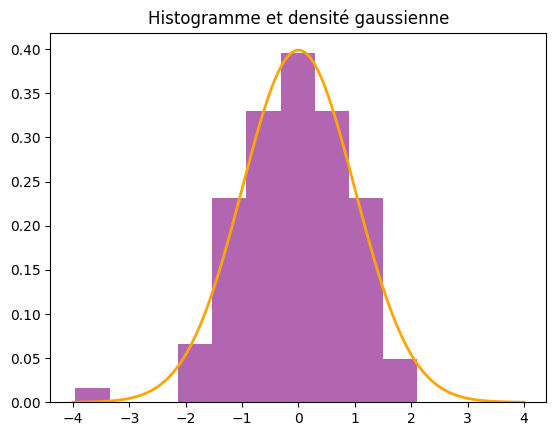

In [261]:
import scipy.stats as stats


n = 100
m = 500
M = stats.expon.rvs(scale=1/2, size=(n,m))

variance = 1/4
espérance = 1/2

histo = np.zeros(n)

for i in range(n) :
    ligne_i = M[i, :]
    somme = np.sum(ligne_i)
    histo[i] = np.sqrt(m/variance)*(somme/m - espérance)

# histogramme associé
plt.hist(histo, bins=10, density=True, alpha=0.6, color='purple', label = 'histogramme')

# densité gaussienne 
x = np.linspace(-4, 4, 100) 
p = stats.norm.pdf(x, 0, 1) # simulation de la densité gaussienne
plt.plot(x, p, 'orange', linewidth=2)

title = "Histogramme et densité gaussienne"
plt.title(title)
plt.show()

Exercice 7 :

In [262]:
# Simuler une variable aléatoire à valeurs dans {0, 1, 2, 3} dont les probabilités sont
# respectivement 0.1, 0.3, 0.2, 0.4. En utilisant np.random.choice puis sans.

# Avec np.random.choice
np.random.seed(0)
n = 1000
p = [0.1, 0.3, 0.2, 0.4]
simu1 = np.random.choice(4, n, p=p)
simu1 = simu1.astype(int)

# Sans np.random.choice
simu2 = np.zeros(n)
for i in range(n):
    r = np.random.rand()
    if r < p[0]:                 # p[0] = 0.1
        simu2[i] = 0
    elif r < p[0] + p[1]:        # p[0] + p[1] = 0.4
        simu2[i] = 1
    elif r < p[0] + p[1] + p[2]: # p[0] + p[1] + p[2] = 0.6
        simu2[i] = 2
    else:                        # p[0] + p[1] + p[2] + p[3] = 1
        simu2[i] = 3
simu2 = simu2.astype(int)

## Exercice 8 

Simulation 1 : À partir de variables uniformes sur [0, 1], générer un n−échantillon de variables de Bernoulli
de paramètre 1/2 à valeurs dans E = {0, 1}. Même question lorsque E = {−1, 1}

In [263]:
n = 500
U = stats.uniform.rvs(loc = 0, scale = 1, size = n)

B = np.zeros(n)
p = 0.5

for i in range(n):
    if U[i] < p:
        B[i] = 1
    else:
        B[i] = 0

B =B.astype(int)

In [264]:
n = 500
U = stats.uniform.rvs(loc = 0, scale = 1, size = n)

B = np.zeros(n)
p = 0.5

for i in range(n):
    if U[i] < p:
        B[i] = 1
    else:
        B[i] = -1

B = B.astype(int)

Simulation 2 : Simuler une variable aléatoire Y de loi uniforme à valeurs dans {0, 1, 2, 3}

In [265]:
n = 1000
p = [1/4,1/4, 1/4, 1/4]
simu1 = np.random.choice(4, n, p=p)
simu1 = simu1.astype(int)

Simulation 3 : À partir de variables uniformes, simuler un n−échantillon (X1, . . . , Xn) de variables aléatoires de loi exponentielle de paramètre 2. Mettre en évidence la loi des grands nombres en traçant la fonction : k → (X1 + . . . + Xk)/k pour k allant de 1 à n

/Users/leajoseph/REPOS GIT/OPS/OPS/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leajoseph/REPOS GIT/OPS/OPS/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


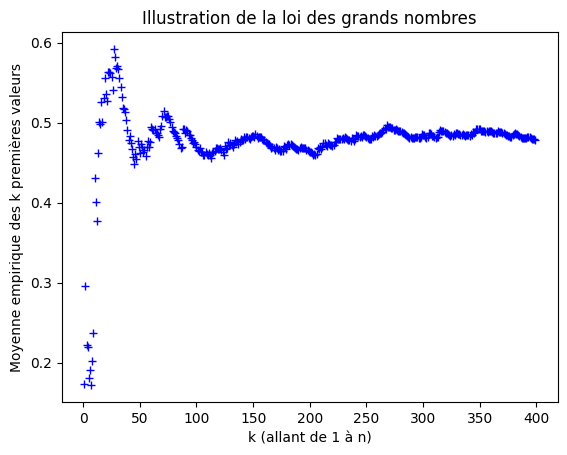

In [266]:
n = 400
U = stats.uniform.rvs(loc = 0, scale = 1, size = n)

E= np.zeros(n)

for i in range(n):
    E[i]= -1/2*np.log(1-U[i])

# On va tracer la fonction pour illustrer la loi des grands nombres
setTitle = "Illustration de la loi des grands nombres"
plt.title(setTitle)
plt.xlabel('k (allant de 1 à n)')
plt.ylabel('Moyenne empirique des k premières valeurs')

for i in range(n) : 
    plt.plot(i, np.mean(E[:i]), '+', color='blue')


Exercice 9 : Utiliser la méthode de simulation ci-dessus pour générer une variable aléatoire de densité x → π/2 sin(πx) sur l’intervalle [0, 1]

In [267]:
def f(x):
    return np.pi/2*np.sin(np.pi*x)

In [268]:
n = 10000

X = stats.uniform.rvs(loc = 0, scale = 1, size = n)
Y = stats.uniform.rvs(loc = 0, scale = np.pi/2, size = n) 

min = -45

for i in range(n):
    if Y[i] < f(X[i]):
        min = i 
        break

print(min)

0
